In [10]:
import numpy as np
import librosa
from IPython.display import Audio

In [11]:
from matplotlib import pyplot as plt
# from matplotlib.ticker import FuncFormatter, NullFormatter

In [12]:
arr = np.array(
    [i for i in range(100)], dtype=np.float32
)

In [13]:
def inter_beat_intervals(beat_times: np.ndarray) -> np.ndarray:
    beat_times = np.asarray(beat_times, dtype=float)
    return np.diff(beat_times)


def ibi_std(beat_times: np.ndarray) -> float:
    """Standard deviation of inter-beat intervals, in seconds.

    The most direct reading of "rubato" from thesis.md: how much the gap
    between consecutive beats varies over the piece. Confounded with
    absolute tempo (a slow piece has bigger IBIs and so more room for
    seconds-scale variation) -- see ibi_cv for a tempo-normalized version.
    """
    ibi = inter_beat_intervals(beat_times)
    if ibi.size < 2:
        return float("nan")
    return float(np.std(ibi))


In [14]:
wav_path = '../logic-resources/drums-rubatoed.wav'

y,sr = librosa.load(wav_path, sr=48000)

Audio(wav_path)

Total samples: 431127
Sampling rate: 48000
Length: 8.9818125  seconds


Text(0.5, 1.0, 'Onsets')

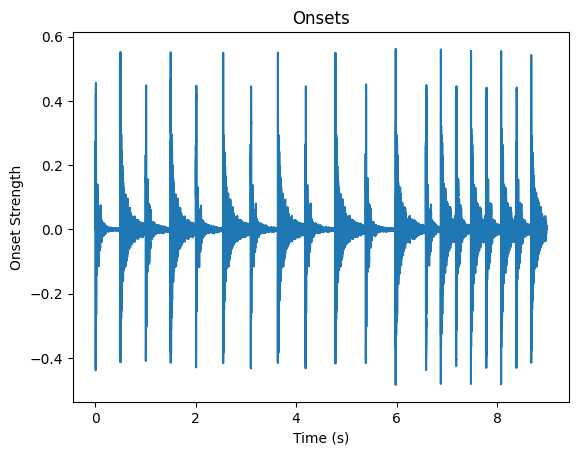

In [15]:
print("Total samples:", len(y))
print("Sampling rate:", sr)
print("Length:", len(y)/sr, " seconds")

plt.plot(np.arange(len(y)) / sr, y)
plt.xlabel("Time (s)")
plt.ylabel("Onset Strength")
plt.title("Onsets")

In [16]:
o_env = librosa.onset.onset_strength(y=y, sr=sr)
times = librosa.times_like(o_env, sr=sr)
onset_frames = librosa.onset.onset_detect(onset_envelope=o_env, sr=sr)

Text(0.5, 1.0, 'Onsets')

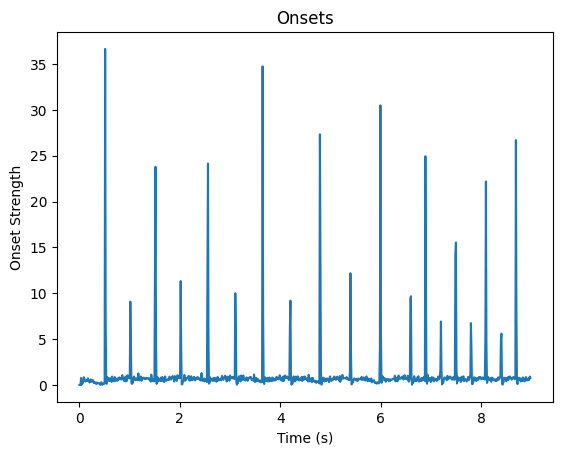

In [21]:
plt.plot(times, o_env)   # x = seconds, y = onset strength
plt.xlabel("Time (s)")
plt.ylabel("Onset Strength")
plt.title("Onsets")

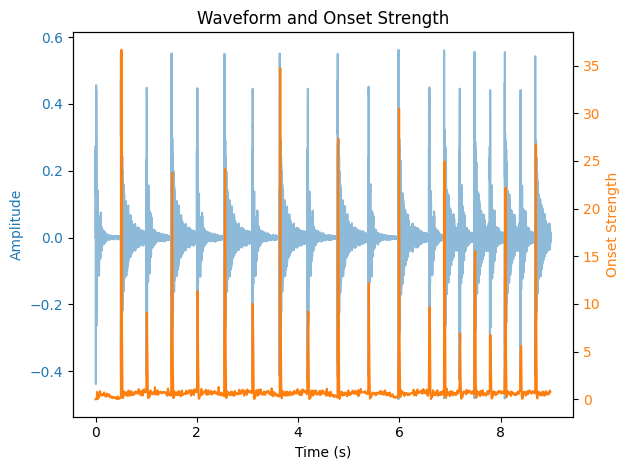

In [19]:
fig, ax1 = plt.subplots()

ax1.plot(np.arange(len(y)) / sr, y, color="tab:blue", alpha=0.5, label="Waveform")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Amplitude", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(times, o_env, color="tab:orange", label="Onset Strength")
ax2.set_ylabel("Onset Strength", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Waveform and Onset Strength")
fig.tight_layout()

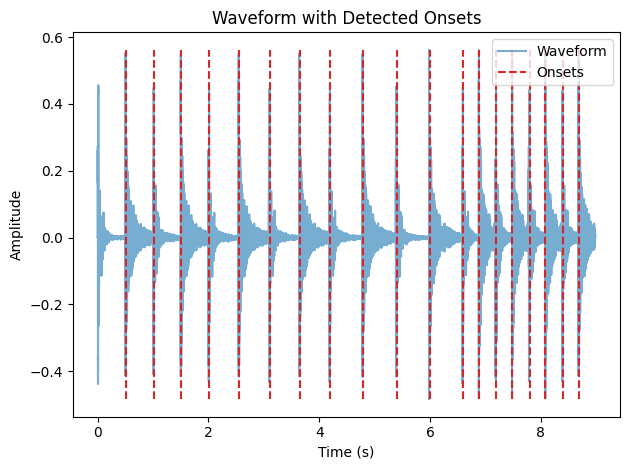

In [24]:
onset_times = librosa.frames_to_time(onset_frames, sr=sr)

fig, ax = plt.subplots()

ax.plot(np.arange(len(y)) / sr, y, color="tab:blue", alpha=0.6, label="Waveform")
ax.vlines(onset_times, ymin=y.min(), ymax=y.max(), color="tab:red", linestyle="--", label="Onsets")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title("Waveform with Detected Onsets")
ax.legend()
fig.tight_layout()

In [ ]:
def inter_beat_intervals(beat_times: np.ndarray) -> np.ndarray:
    beat_times = np.asarray(beat_times, dtype=float)
    return np.diff(beat_times)


def ibi_std(beat_times: np.ndarray) -> float:
    """Standard deviation of inter-beat intervals, in seconds.

    The most direct reading of "rubato" from thesis.md: how much the gap
    between consecutive beats varies over the piece. Confounded with
    absolute tempo (a slow piece has bigger IBIs and so more room for
    seconds-scale variation) -- see ibi_cv for a tempo-normalized version.
    """
    ibi = inter_beat_intervals(beat_times)
    if ibi.size < 2:
        return float("nan")
    return float(np.std(ibi))


In [18]:
arr[50]+= 0.5
arr[51]+= 0.6
arr[52]+= 0.7
arr[53]+= 0.6
arr[52]+= 0.5
dup = np.asarray(arr)

beat_difs = np.diff(dup)
std = np.std(beat_difs)
# print(std)
# print(np.mean(beat_difs))
print(beat_difs)
print(np.shape(beat_difs))
mean = np.mean(beat_difs)
cv = std/mean if mean else float("nan")

window = 10
half = window // 2
tempo = 60/beat_difs
padded = np.pad(tempo, (window, window), mode="edge")
print(np.shape(padded))

trend = np.array(
    [np.median(padded[i : i + window]) for i in range(len(tempo))]
)
print(np.shape(np.asarray([padded[i : i + window] for i in range(len(tempo))])))
print(np.shape(trend))

residual = tempo - trend

residual = tempo - trend
local_tempo_wobble = float(np.std(residual))


x =  {
        "n_beats": len(arr),
        "duration": float(arr[-1] - arr[0]) if len(arr) else 0.0,
        "ibi_std": std,
        "ibi_cv": cv,
        "local_tempo_wobble": local_tempo_wobble,
    }


[1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.5        1.0999985  1.6000023  0.3999977  0.40000153
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.        ]
(99,)
(119,)
